# BBN abundance evolution

Plots $A_i Y_i(t)$ for each nuclide vs cosmic time, for the **small** (12-reaction,
8-nuclide), **large, amax=8** (68-reaction, 12-nuclide, equivalent to the old
"medium" network) and **large** (~429-reaction, ~59-nuclide) networks, with a secondary axis showing $T_\gamma$ in MeV.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from primat.main import PRIMAT
from primat.plotting import nuclide_styles   # shared element-colour/isotope-style map

In [2]:
def add_temperature_axis(ax, instance, T_ticks_MeV):
    """Add a top x-axis showing T_gamma in MeV."""
    t_ticks = [float(instance.t_of_T(T)) for T in T_ticks_MeV]
    ax2 = ax.twiny()
    ax2.set_xscale('log')
    ax2.set_xlim(ax.get_xlim())
    ax2.set_xticks(t_ticks)
    ax2.set_xticklabels([str(T) for T in T_ticks_MeV])
    ax2.set_xlabel(r'$T_\gamma$ [MeV]')
    return ax2

t = np.logspace(0, 6, 500)   # 1 s to 1e10 s
T_ticks_MeV = [1.0, 0.5, 0.2, 0.1, 0.05, 0.02, 0.01]

## Small network (12 reactions, 8 nuclides)

In [3]:
r_small = PRIMAT({'network': 'small', 'verbose': True})


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                                 ┃
┃   ░█▀█░█░█░█▀█░█▀▄░▀█▀░█▄█░█▀█░▀█▀              ┃
┃   ░█▀▀░░█░░█▀▀░█▀▄░░█░░█░█░█▀█░░█░              ┃
┃   ░▀░░░░▀░░▀░░░▀░▀░▀▀▀░▀░▀░▀░▀░░▀░              ┃
┃                                                 ┃
┃    Welcome to PyPRIMAT v0.1.0 — Cyril Pitrou    ┃
┃                                                 ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

[init]  numba detected: using it for JIT compilation.
[init]  Electron-thermo tables loaded from cache (2000 points).
[init]  Tables loaded.
[rates] Building 'small' network from text lists.
[rates] MT network: 12 reactions over 8 nuclides.
[rates] LT network: 12 reactions over 8 nuclides.
------------------------------------------------------------
Loaded 13 reactions (LT network):
------------------------------------------------------------
  n <-> p                 [weak n<->p]
  n + p <-> H2            [And06]
  H2 + p <

[nucl]  Solving neutron decoupling at high temperature era


[nucl]  [HT] Finished solve_ivp in 0.12 s (status=0, nfev=3402)


[nucl]  Solving nuclear network at mid temperature era


[nucl]  [MT] Finished solve_ivp (small network, 8 species) in 0.68 s (status=0, nfev=7568)


[nucl]  Solving nuclear network at low temperature era


[nucl]  [LT] Finished solve_ivp (small network, 8 nuclides) in 0.92 s (status=0, nfev=12680)


--------------------------------------------------
Predicted primordial abundances at the end of BBN (8 numerically solved nuclides)
--------------------------------------------------
  Yn    = 3.997346e-16
  Yp    = 7.529431e-01
  YH2   = 1.833405e-05
  YH3   = 5.849820e-08
  YHe3  = 7.770387e-06
  YHe4  = 6.174918e-02
  YLi7  = 2.180916e-11
  YBe7  = 3.969503e-10


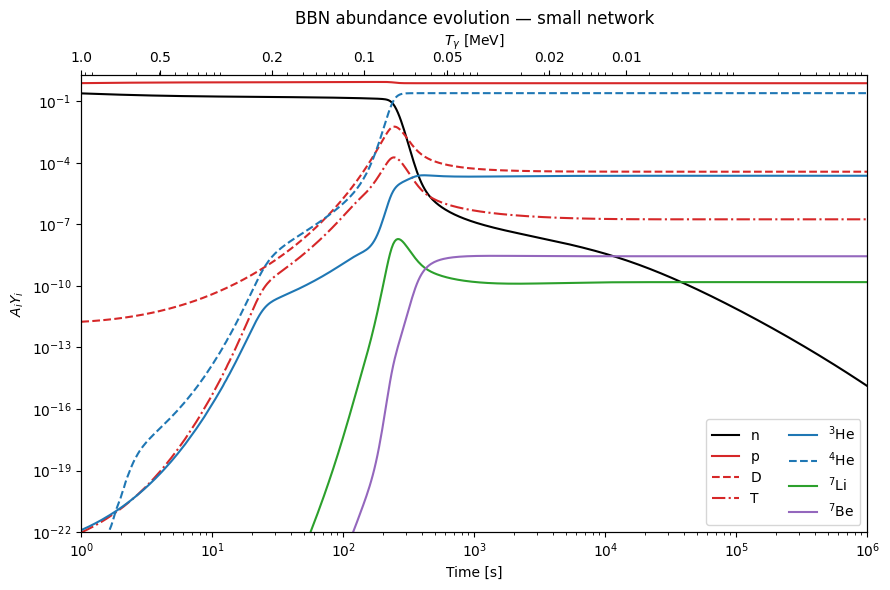

In [4]:
# Colours per chemical element, line style per isotope (shared convention).
styles = nuclide_styles(r_small.abundance_names)

fig, ax = plt.subplots(figsize=(9, 6))
for name in r_small.abundance_names:
    color, ls, label = styles[name]
    vals = r_small.A[name] * r_small[name](t)
    mask = vals > 0
    if mask.any():
        ax.plot(t[mask], vals[mask], color=color, linestyle=ls, label=label)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Time [s]')
ax.set_ylabel(r'$A_i Y_i$')
ax.set_xlim(1, 1e6)
ax.set_ylim(1e-22, 2)
ax.legend(ncol=2)
ax.set_title('BBN abundance evolution — small network')
add_temperature_axis(ax, r_small, T_ticks_MeV)

plt.tight_layout()
plt.savefig('plots/abundance_evolution_small.pdf', bbox_inches='tight')
plt.show()

## Large network, amax=8 (68 reactions, 12 nuclides)

In [5]:
r_amax8 = PRIMAT({'network': 'large', 'amax': 8, 'verbose': True})


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                                 ┃
┃   ░█▀█░█░█░█▀█░█▀▄░▀█▀░█▄█░█▀█░▀█▀              ┃
┃   ░█▀▀░░█░░█▀▀░█▀▄░░█░░█░█░█▀█░░█░              ┃
┃   ░▀░░░░▀░░▀░░░▀░▀░▀▀▀░▀░▀░▀░▀░░▀░              ┃
┃                                                 ┃
┃    Welcome to PyPRIMAT v0.1.0 — Cyril Pitrou    ┃
┃                                                 ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

[init]  numba detected: using it for JIT compilation.
[init]  Electron-thermo tables loaded from cache (2000 points).
[init]  Tables loaded.
[rates] Building 'large' network from text lists.
[rates] MT network: 17 reactions over 12 nuclides.
[rates] LT network: 67 reactions over 12 nuclides.
------------------------------------------------------------
Loaded 68 reactions (LT network):
------------------------------------------------------------
  n <-> p                           [weak n<->p]
  B8 <-> He4 + He4              

[nucl]  Solving neutron decoupling at high temperature era


[nucl]  [HT] Finished solve_ivp in 0.15 s (status=0, nfev=3402)


[nucl]  Solving nuclear network at mid temperature era


[nucl]  [MT] Finished solve_ivp (large network, 12 species) in 0.55 s (status=0, nfev=7212)


[nucl]  Solving nuclear network at low temperature era


[nucl]  [LT] Finished solve_ivp (large network, 12 nuclides) in 1.60 s (status=0, nfev=21033)


--------------------------------------------------
Predicted primordial abundances at the end of BBN (12 numerically solved nuclides)
--------------------------------------------------
  Yn    = 3.996487e-16
  Yp    = 7.529393e-01
  YH2   = 1.833903e-05
  YH3   = 5.836874e-08
  YHe3  = 7.768977e-06
  YHe4  = 6.175013e-02
  YLi7  = 9.183065e-11
  YBe7  = 3.226161e-10
  YHe6  = 1.102045e-60
  YLi8  = 8.648516e-33
  YLi6  = 5.876044e-15
  YB8   = 9.091270e-34


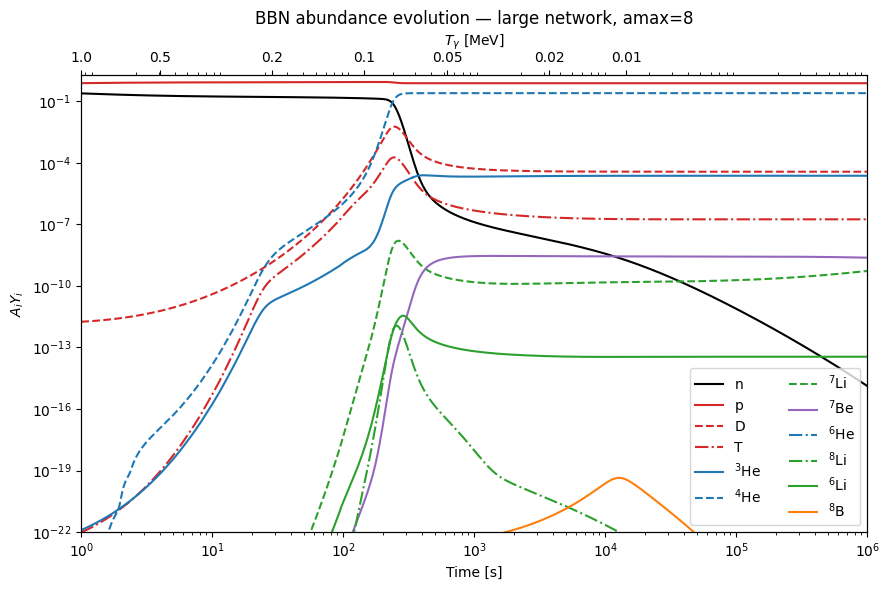

In [6]:
styles = nuclide_styles(r_amax8.abundance_names)

fig, ax = plt.subplots(figsize=(9, 6))
for name in r_amax8.abundance_names:
    color, ls, label = styles[name]
    vals = r_amax8.A[name] * r_amax8[name](t)
    mask = vals > 0
    if mask.any():
        ax.plot(t[mask], vals[mask], color=color, linestyle=ls, label=label)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Time [s]'); ax.set_ylabel(r'$A_i Y_i$')
ax.set_xlim(1, 1e6); ax.set_ylim(1e-22, 2)
ax.legend(ncol=2); add_temperature_axis(ax, r_amax8, T_ticks_MeV)
ax.set_title('BBN abundance evolution — large network, amax=8')
plt.tight_layout(); plt.show()

## Large network (~429 reactions, ~59 nuclides)

Every tracked nuclide is plotted.  The light elements match the large network, amax=8;
the heavy-nuclide tail is approximate (limited by the AC2024 rate floors).  Lower
`atol_large_LT` (default `1e-25`) to resolve smaller abundances at extra cost.

In [7]:
r_large = PRIMAT({'network': 'large', 'verbose': True})
# To resolve tinier nuclides, e.g.: PRIMAT({'network':'large','atol_large_LT':1e-30})


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                                 ┃
┃   ░█▀█░█░█░█▀█░█▀▄░▀█▀░█▄█░█▀█░▀█▀              ┃
┃   ░█▀▀░░█░░█▀▀░█▀▄░░█░░█░█░█▀█░░█░              ┃
┃   ░▀░░░░▀░░▀░░░▀░▀░▀▀▀░▀░▀░▀░▀░░▀░              ┃
┃                                                 ┃
┃    Welcome to PyPRIMAT v0.1.0 — Cyril Pitrou    ┃
┃                                                 ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

[init]  numba detected: using it for JIT compilation.
[init]  Electron-thermo tables loaded from cache (2000 points).
[init]  Tables loaded.
[rates] Building 'large' network from text lists.


[rates] MT network: 17 reactions over 12 nuclides.
[rates] LT network: 428 reactions over 59 nuclides.
------------------------------------------------------------
Loaded 429 reactions (LT network):
------------------------------------------------------------
  n <-> p                           [weak n<->p]
  B10 + He3 <-> C11 + H2            [TALYS2]
  B10 + He3 <-> C12 + p             [TALYS2]
  B10 + He3 <-> N12 + n             [TALYS2]
  B10 + He3 <-> N13                 [TALYS2]
  B10 + He4 <-> C12 + H2            [TALYS2]
  B10 + He4 <-> C13 + p             [TALYS2]
  B10 + He4 <-> N13 + n             [CF88  (analytic, PRIMAT-main.m)]
  B10 + He4 <-> N14                 [TALYS2]
  B10 + H2 <-> B11 + p              [TALYS2]
  B10 + H2 <-> C11 + n              [TALYS2]
  B10 + H2 <-> C12                  [TALYS2]
  B10 + H2 <-> He4 + He4 + He4      [TALYS2]
  B10 + n <-> B11                   [TALYS2]
  B10 + n <-> Be10 + p              [TALYS2]
  B10 + n <-> He4 + He4 + H3        

[nucl]  Solving neutron decoupling at high temperature era


[nucl]  [HT] Finished solve_ivp in 0.12 s (status=0, nfev=3402)


[nucl]  Solving nuclear network at mid temperature era


[nucl]  [MT] Finished solve_ivp (large network, 12 species) in 0.53 s (status=0, nfev=7212)


[nucl]  Solving nuclear network at low temperature era


[nucl]  [LT] Finished solve_ivp (large network, 59 nuclides) in 1.81 s (status=0, nfev=17838)


--------------------------------------------------
Predicted primordial abundances at the end of BBN (59 numerically solved nuclides)
--------------------------------------------------
  Yn    = 3.996513e-16
  Yp    = 7.529393e-01
  YH2   = 1.833911e-05
  YH3   = 5.836888e-08
  YHe3  = 7.768991e-06
  YHe4  = 6.175013e-02
  YLi7  = 9.182964e-11
  YBe7  = 3.226114e-10
  YHe6  = 1.102060e-60
  YLi8  = 8.648478e-33
  YLi6  = 5.876180e-15
  YB8   = 9.091138e-34
  YLi9  = 9.398422e-56
  YBe9  = 6.711612e-19
  YBe10 = 4.700597e-27
  YBe11 = 7.209681e-49
  YBe12 = 1.028231e-73
  YB10  = 1.843208e-21
  YB11  = 2.472362e-16
  YB12  = 3.214351e-40
  YB13  = 6.825932e-64
  YB14  = 3.524756e-87
  YB15  = 5.647580e-113
  YC9   = 2.751517e-62
  YC10  = 9.456882e-59
  YC11  = 2.482758e-41
  YC12  = 4.213263e-16
  YC13  = 1.105126e-16
  YC14  = 2.137911e-18
  YC15  = 3.668112e-42
  YC16  = 1.155049e-64
  YN12  = 2.817430e-72
  YN13  = 2.050248e-41
  YN14  = 5.312651e-17
  YN15  = 8.736248e-19
  YN16  =

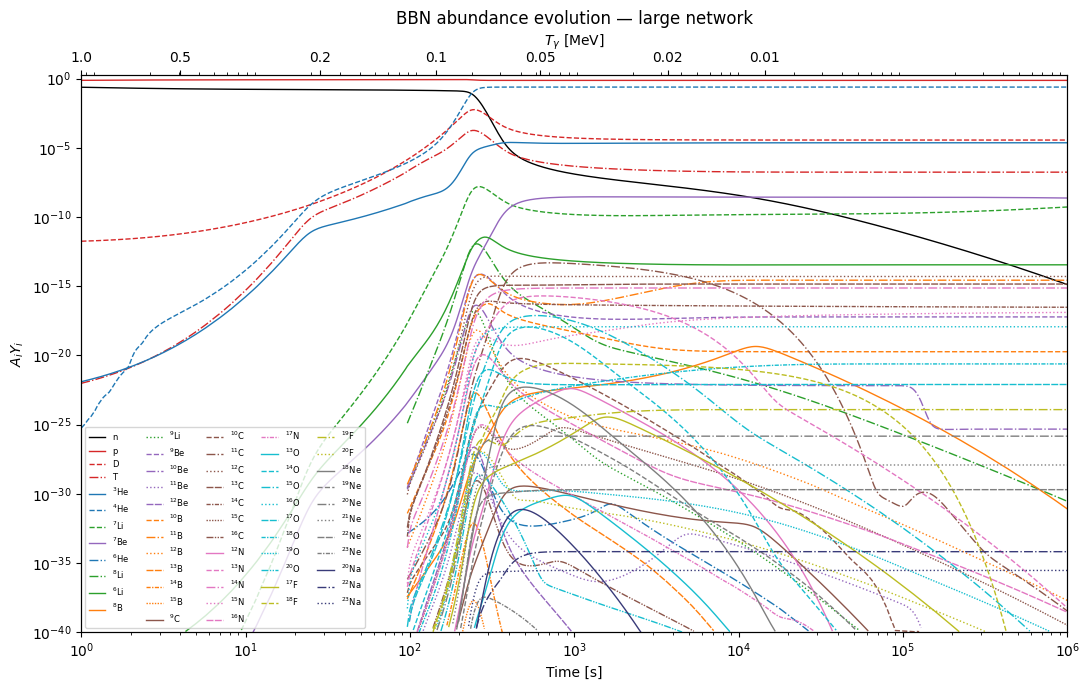

In [8]:
names = r_large.abundance_names               # all ~59 tracked nuclides
styles = nuclide_styles(names)                # element colour + isotope line style

fig, ax = plt.subplots(figsize=(11, 7))
for name in names:
    color, ls, label = styles[name]
    vals = r_large.A[name] * r_large[name](t)
    mask = vals > 1e-40                        # only drop curves below the y-axis floor
    if mask.any():
        ax.plot(t[mask], vals[mask], color=color, linestyle=ls, lw=1.0, label=label)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Time [s]'); ax.set_ylabel(r'$A_i Y_i$')
ax.set_xlim(1, 1e6); ax.set_ylim(1e-40, 2)
ax.legend(ncol=5, fontsize=6, loc='lower left')
ax.set_title('BBN abundance evolution — large network')
add_temperature_axis(ax, r_large, T_ticks_MeV)
plt.tight_layout(); plt.show()